<a href="https://colab.research.google.com/github/Yukta-bmsce/ML-LAB/blob/main/1WA23CS055%5BRandomforest%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Iris Dataset Random Forest
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the data
# Make sure 'iris.csv' is uploaded to your current Colab session
iris_df = pd.read_csv('iris.csv')

# 2. Separate features (X) and target (y)
X_iris = iris_df.drop('species', axis=1)
y_iris = iris_df['species']

# 3. Split into training and testing sets
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# 4. Initialize and train the Random Forest Classifier
# We are planting 100 trees in our forest!
rf_iris = RandomForestClassifier(n_estimators=100, random_state=42)
rf_iris.fit(X_train_i, y_train_i)

# 5. Make predictions and evaluate
predictions_iris = rf_iris.predict(X_test_i)
print("--- Iris Dataset Results ---")
print(f"Accuracy: {accuracy_score(y_test_i, predictions_iris) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test_i, predictions_iris))

--- Iris Dataset Results ---
Accuracy: 100.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [ ]:
# Cell 2: Drug Dataset Random Forest
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the data
drug_df = pd.read_csv('drug.csv')

# 2. Separate features (X) and target (y)
X_drug = drug_df.drop('Drug', axis=1)
y_drug = drug_df['Drug']

# 3. Preprocessing: Convert categorical text data into numbers
# pd.get_dummies will magically turn 'Sex', 'BP', and 'Cholesterol' into numerical columns
X_drug_encoded = pd.get_dummies(X_drug, drop_first=True)

# 4. Split into training and testing sets
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_drug_encoded, y_drug, test_size=0.2, random_state=42)

# 5. Initialize and train the Random Forest
rf_drug = RandomForestClassifier(n_estimators=100, random_state=42)
rf_drug.fit(X_train_d, y_train_d)

# 6. Make predictions and evaluate
predictions_drug = rf_drug.predict(X_test_d)
print("--- Drug Dataset Results ---")
print(f"Accuracy: {accuracy_score(y_test_d, predictions_drug) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test_d, predictions_drug))

--- Drug Dataset Results ---
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         6
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        11
       drugY       1.00      1.00      1.00        15

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



=== Diabetes Dataset Results ===
Accuracy Score: 72.08%

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154


Confusion matrix saved as 'diabetes_confusion_matrix.png'


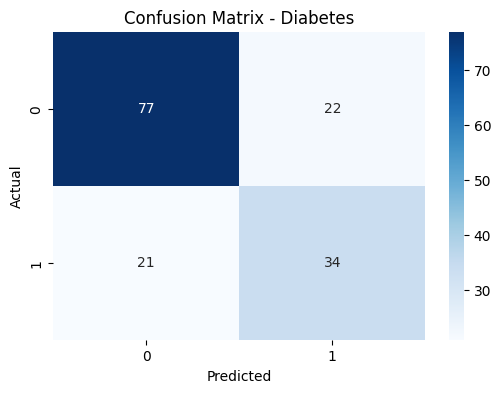

In [ ]:
# Cell 1: Diabetes Dataset - Random Forest
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
diabetes_df = pd.read_csv('diabetes.csv')

# 2. Separate features (X) and target (y)
X_diab = diabetes_df.drop('Outcome', axis=1)
y_diab = diabetes_df['Outcome']

# 3. Split data: 80% training, 20% testing (As per PPT)
X_train_diab, X_test_diab, y_train_diab, y_test_diab = train_test_split(X_diab, y_diab, test_size=0.2, random_state=42)

# 4. Feature Scaling (As per Lab 6 requirement)
scaler = StandardScaler()
X_train_diab_scaled = scaler.fit_transform(X_train_diab)
X_test_diab_scaled = scaler.transform(X_test_diab)

# 5. Build and Train the Random Forest
rf_diab = RandomForestClassifier(n_estimators=100, random_state=42)
rf_diab.fit(X_train_diab_scaled, y_train_diab)

# 6. Predict and Evaluate
y_pred_diab = rf_diab.predict(X_test_diab_scaled)

print("=== Diabetes Dataset Results ===")
print(f"Accuracy Score: {accuracy_score(y_test_diab, y_pred_diab) * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test_diab, y_pred_diab))

# 7. Plot Confusion Matrix
cm_diab = confusion_matrix(y_test_diab, y_pred_diab)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_diab, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Diabetes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('diabetes_confusion_matrix.png') # Saving as per your VM quirks!
print("\nConfusion matrix saved as 'diabetes_confusion_matrix.png'")

=== Heart Dataset: Finding Best n_estimators ===
n_estimators = 10: Accuracy = 85.25%
n_estimators = 50: Accuracy = 86.89%
n_estimators = 100: Accuracy = 83.61%
n_estimators = 150: Accuracy = 83.61%
n_estimators = 200: Accuracy = 83.61%

Best accuracy achieved with n_estimators = 50

Classification Report (Best Model):
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61


Confusion matrix saved as 'heart_confusion_matrix.png'


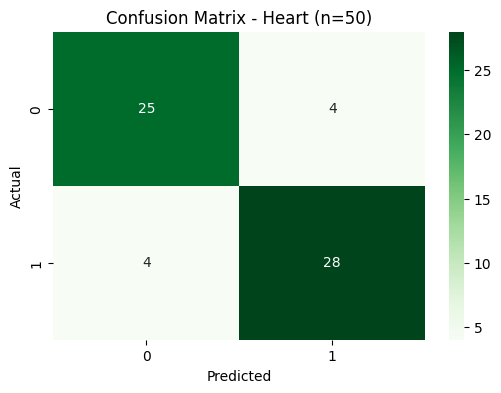

In [ ]:
# Cell 2: Heart Dataset - Random Forest Tuning
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
heart_df = pd.read_csv('heart.csv')

# 2. Separate features (X) and target (y)
X_heart = heart_df.drop('target', axis=1)
y_heart = heart_df['target']

# 3. Split data: 80% training, 20% testing
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42)

# 4. Experiment with different number of trees (n_estimators) to find the max score
estimators_list = [10, 50, 100, 150, 200]
best_score = 0
best_n = 0
best_model = None

print("=== Heart Dataset: Finding Best n_estimators ===")
for n in estimators_list:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train_h, y_train_h)
    temp_pred = rf_temp.predict(X_test_h)
    score = accuracy_score(y_test_h, temp_pred)
    print(f"n_estimators = {n}: Accuracy = {score * 100:.2f}%")

    if score > best_score:
        best_score = score
        best_n = n
        best_model = rf_temp

print(f"\nBest accuracy achieved with n_estimators = {best_n}")

# 5. Evaluate the best model
y_pred_h = best_model.predict(X_test_h)

print("\nClassification Report (Best Model):")
print(classification_report(y_test_h, y_pred_h))

# 6. Plot Confusion Matrix
cm_heart = confusion_matrix(y_test_h, y_pred_h)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_heart, annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix - Heart (n={best_n})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('heart_confusion_matrix.png')
print("\nConfusion matrix saved as 'heart_confusion_matrix.png'")